In [1]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
#datos de ingreso
dia_ivd = '20260201'
dia_fvd = '20260512'

In [3]:
# Ruta de la carpeta que contiene los archivos de desglosados zonal
ruta_carpeta = 'Z:/01 base_datos/41 Informe Diario CCZ/Blogger/Datos diarios  dia vencido/Perdidos'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ivd}'
fecha_fin = f'{dia_fvd}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):

    if nombre_archivo.endswith('_bitacora perdidos.csv'):

        # Extraer la fecha del nombre del archivo (YYYYMMDD)
        fecha_archivo = nombre_archivo[:8]

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:

            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)

            # Leer el archivo
            df = pd.read_csv(ruta_archivo, encoding='latin')

            # Eliminar filas completamente vacías
            df = df.dropna(how='all')

            # Crear la columna Fecha a partir del nombre del archivo
            df['Fecha'] = pd.to_datetime(fecha_archivo, format='%Y%m%d')

            # Agregar a la lista
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    perdidos = pd.concat(dataframes, ignore_index=True)
else:
    print("No se encontraron archivos para consolidar.")

# Verificar resultado
perdidos.head()

,FECHA,SERVICIO VEHICULO,RUTA,OPERADOR,CODIGO,CEDULA,HORA INICIO,HORA FINAL,MOTIVO,CAUSA,...,KMS PLANIFICADOS,KMS REALIZADOS,KMS PERDIDOS,PARTE DE TRABAJO,USUARIO REGISTRO,FECHA REGISTRO,REPORTADO A TRANSMILENIO,VEHICULO,PATIO,Fecha
0,2026-02-01,CE0590004,539,JONATHAN JOSE MONTIEL ARRIETA,510074.0,1.066521e+09,10:17:00,13:05:00,Falta de Movil,Movil llega tarde - Incorporación,...,"42,706","34,038","8,668",1.0,KAREN LORENA BARRERA SERRANO,2026-02-01 11:07:48,NO,Z50-4211,PATIO TINTAL,2026-02-01
1,2026-02-01,CE0590008,539,ALFONSO VIDAL FANDIÑO PEREZ,501335.0,1.611230e+07,13:53:00,16:39:00,Operador,Operador en otro servicio,...,"43,656",0,"43,656",1.0,WILSON ABEL TORRES FAJARDO,2026-02-01 14:25:05,NO,Z50-7122,PATIO TINTAL 2,2026-02-01
2,2026-02-01,CE0590008,539,ALFONSO VIDAL FANDIÑO PEREZ,501335.0,1.611230e+07,16:45:00,19:22:00,Operador,Operador en otro servicio,...,"42,706",0,"42,706",1.0,WILSON ABEL TORRES FAJARDO,2026-02-01 14:25:05,NO,Z50-7122,PATIO TINTAL 2,2026-02-01
3,2026-02-01,CE0590009,539,CRISTIAN EDUARDO FORERO CASTRO,505613.0,1.014257e+09,20:33:00,22:46:00,Operador,Operador en otro servicio,...,"43,656",0,"43,656",2.0,WILSON ABEL TORRES FAJARDO,2026-02-01 21:21:00,NO,CT-E900,PATIO TINTAL 2,2026-02-01
4,2026-02-01,CE0590010,539,OMAR ANDRES CORTES ROMERO,506905.0,1.013597e+09,21:21:00,23:12:00,Operatividad,Retraso por Congestión,...,"42,706",0,"42,706",2.0,WILSON ABEL TORRES FAJARDO,2026-02-01 22:02:43,NO,Z50-4182,PATIO TINTAL,2026-02-01


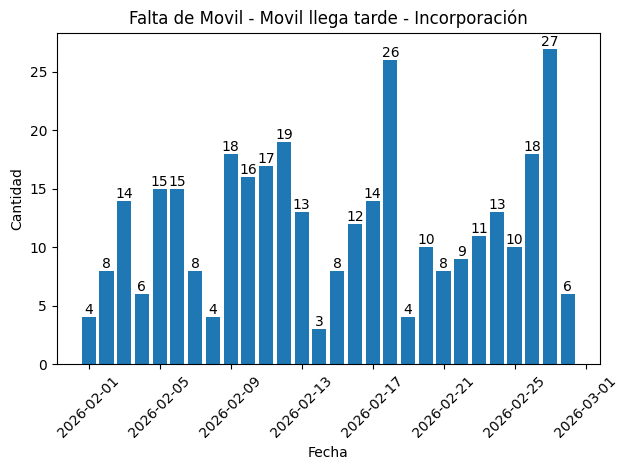

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar tipo fecha
perdidos["Fecha"] = pd.to_datetime(perdidos["Fecha"])

# Filtrar por MOTIVO y CAUSA
df_filtrado = perdidos[
    (perdidos["MOTIVO"] == "Falta de Movil") &
    (perdidos["CAUSA"] == "Movil llega tarde - Incorporación")
]

# Agrupar por Fecha
grafica_data = (
    df_filtrado
    .groupby("Fecha")
    .size()
    .reset_index(name="cantidad")
    .sort_values("Fecha")
)

# Crear gráfico de columnas
plt.figure()
barras = plt.bar(grafica_data["Fecha"], grafica_data["cantidad"])

# Etiquetas de datos
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )

plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.title("Falta de Movil - Movil llega tarde - Incorporación")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

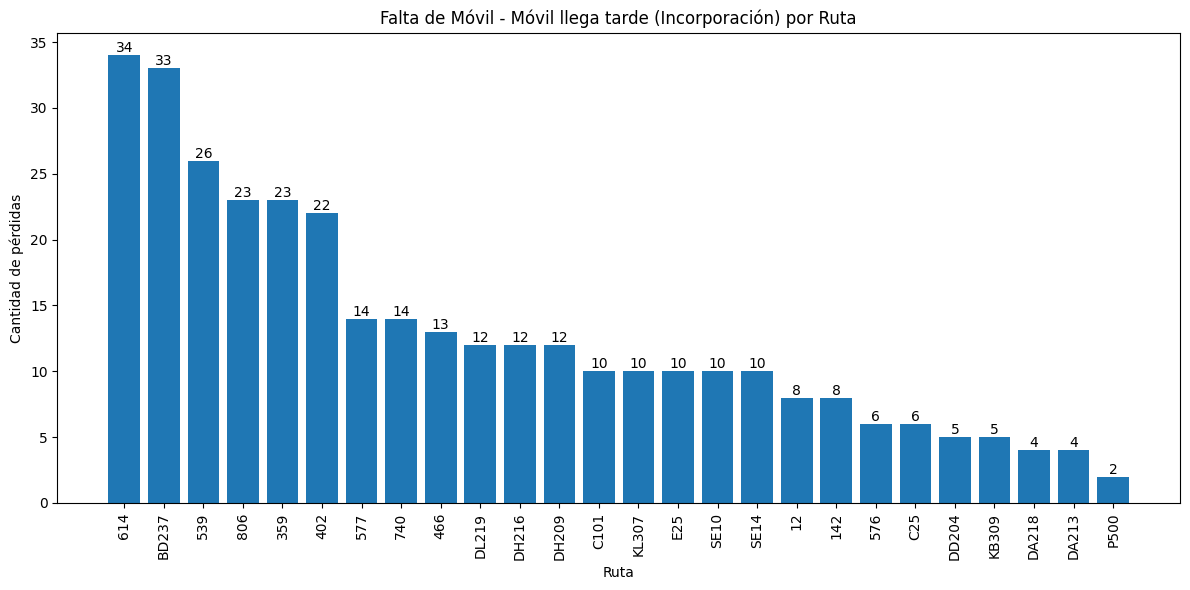

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar tipo fecha
perdidos["Fecha"] = pd.to_datetime(perdidos["Fecha"])

# Filtrar condición
df_filtrado = perdidos[
    (perdidos["MOTIVO"] == "Falta de Movil") &
    (perdidos["CAUSA"] == "Movil llega tarde - Incorporación")
]

# Agrupar por Ruta
grafica_ruta = (
    df_filtrado
    .groupby("RUTA")
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

# Gráfico columnas
plt.figure(figsize=(12,6))
barras = plt.bar(grafica_ruta["RUTA"].astype(str),
                 grafica_ruta["cantidad"])

# Etiquetas de datos
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        int(altura),
        ha="center",
        va="bottom"
    )

plt.xlabel("Ruta")
plt.ylabel("Cantidad de pérdidas")
plt.title("Falta de Móvil - Móvil llega tarde (Incorporación) por Ruta")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir a datetime
perdidos["HORA INICIO"] = pd.to_datetime(
    perdidos["HORA INICIO"], 
    errors="coerce"
)

# Extraer hora
perdidos["hora"] = perdidos["HORA INICIO"].dt.hour

# Definir franjas
bins = [0, 6, 9, 12, 15, 18, 21, 24]
labels = [
    "00-06",
    "06-09",
    "09-12",
    "12-15",
    "15-18",
    "18-21",
    "21-24"
]

perdidos["Franja"] = pd.cut(
    perdidos["hora"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_14436\649495675.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  perdidos["HORA INICIO"] = pd.to_datetime(


In [7]:
df_filtrado = perdidos[
    (perdidos["MOTIVO"] == "Falta de Movil") &
    (perdidos["CAUSA"] == "Movil llega tarde - Incorporación")
]

In [8]:
grafica_franja = (
    df_filtrado
    .groupby("Franja")
    .size()
    .reset_index(name="cantidad")
    .sort_values("Franja")
)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_14436\2017253043.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Franja")


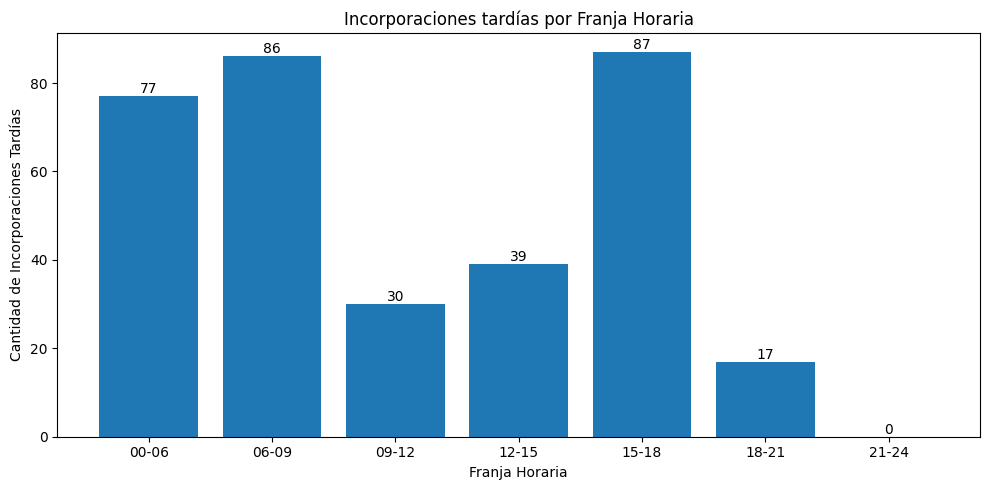

In [9]:
plt.figure(figsize=(10,5))
barras = plt.bar(
    grafica_franja["Franja"].astype(str),
    grafica_franja["cantidad"]
)

# Etiquetas de datos
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        int(altura),
        ha="center",
        va="bottom"
    )

plt.xlabel("Franja Horaria")
plt.ylabel("Cantidad de Incorporaciones Tardías")
plt.title("Incorporaciones tardías por Franja Horaria")

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Total general de perdidos
total_general = len(perdidos)

# Filtrar motivo y causa objetivo
df_objetivo = perdidos[
    (perdidos["MOTIVO"] == "Falta de Movil") &
    (perdidos["CAUSA"] == "Movil llega tarde - Incorporación")
]

total_objetivo = len(df_objetivo)
total_resto = total_general - total_objetivo

porcentaje_objetivo = round((total_objetivo / total_general) * 100, 1)

print("Total perdidos:", total_general)
print("Falta de Movil - Incorporación Tarde:", total_objetivo)
print("Representa:", porcentaje_objetivo, "% del total")

Total perdidos: 23203
Falta de Movil - Incorporación Tarde: 336
Representa: 1.4 % del total


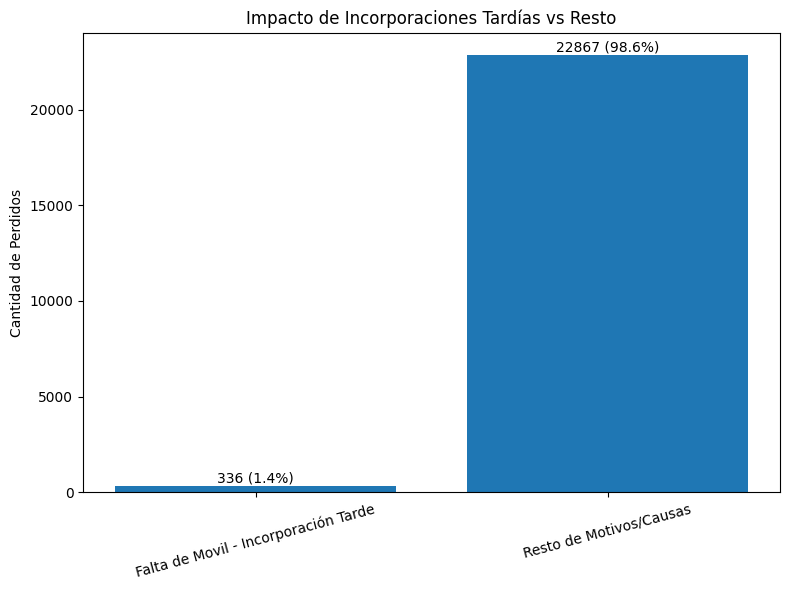

In [11]:
# Crear dataframe resumen
grafica_data = pd.DataFrame({
    "Categoria": [
        "Falta de Movil - Incorporación Tarde",
        "Resto de Motivos/Causas"
    ],
    "Cantidad": [
        total_objetivo,
        total_resto
    ]
})

grafica_data["Porcentaje"] = (
    grafica_data["Cantidad"] / total_general * 100
).round(1)

# Gráfico
plt.figure(figsize=(8,6))
barras = plt.bar(grafica_data["Categoria"],
                 grafica_data["Cantidad"])

# Etiquetas (cantidad + %)
for i, barra in enumerate(barras):
    altura = barra.get_height()
    etiqueta = f"{int(altura)} ({grafica_data['Porcentaje'][i]}%)"
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        etiqueta,
        ha="center",
        va="bottom"
    )

plt.ylabel("Cantidad de Perdidos")
plt.title("Impacto de Incorporaciones Tardías vs Resto")
plt.xticks(rotation=15)

plt.tight_layout()
# plt.show()

In [12]:
df_objetivo = perdidos[
    (perdidos["MOTIVO"] == "Falta de Movil") &
    (perdidos["CAUSA"] == "Movil llega tarde - Incorporación")
]

In [13]:
tabla_ruta_franja = (
    df_objetivo
    .groupby(["RUTA", "Franja"])
    .size()
    .reset_index(name="cantidad")
)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_14436\2897745065.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["RUTA", "Franja"])


In [14]:
tabla_ruta_franja = tabla_ruta_franja.sort_values(
    ["RUTA", "cantidad"],
    ascending=[True, False]
)

tabla_ruta_franja.head(20)

,RUTA,Franja,cantidad
1,12,06-09,3
0,12,00-06,2
2,12,09-12,1
4,12,15-18,1
5,12,18-21,1
3,12,12-15,0
6,12,21-24,0
11,142,15-18,4
7,142,00-06,1
8,142,06-09,1


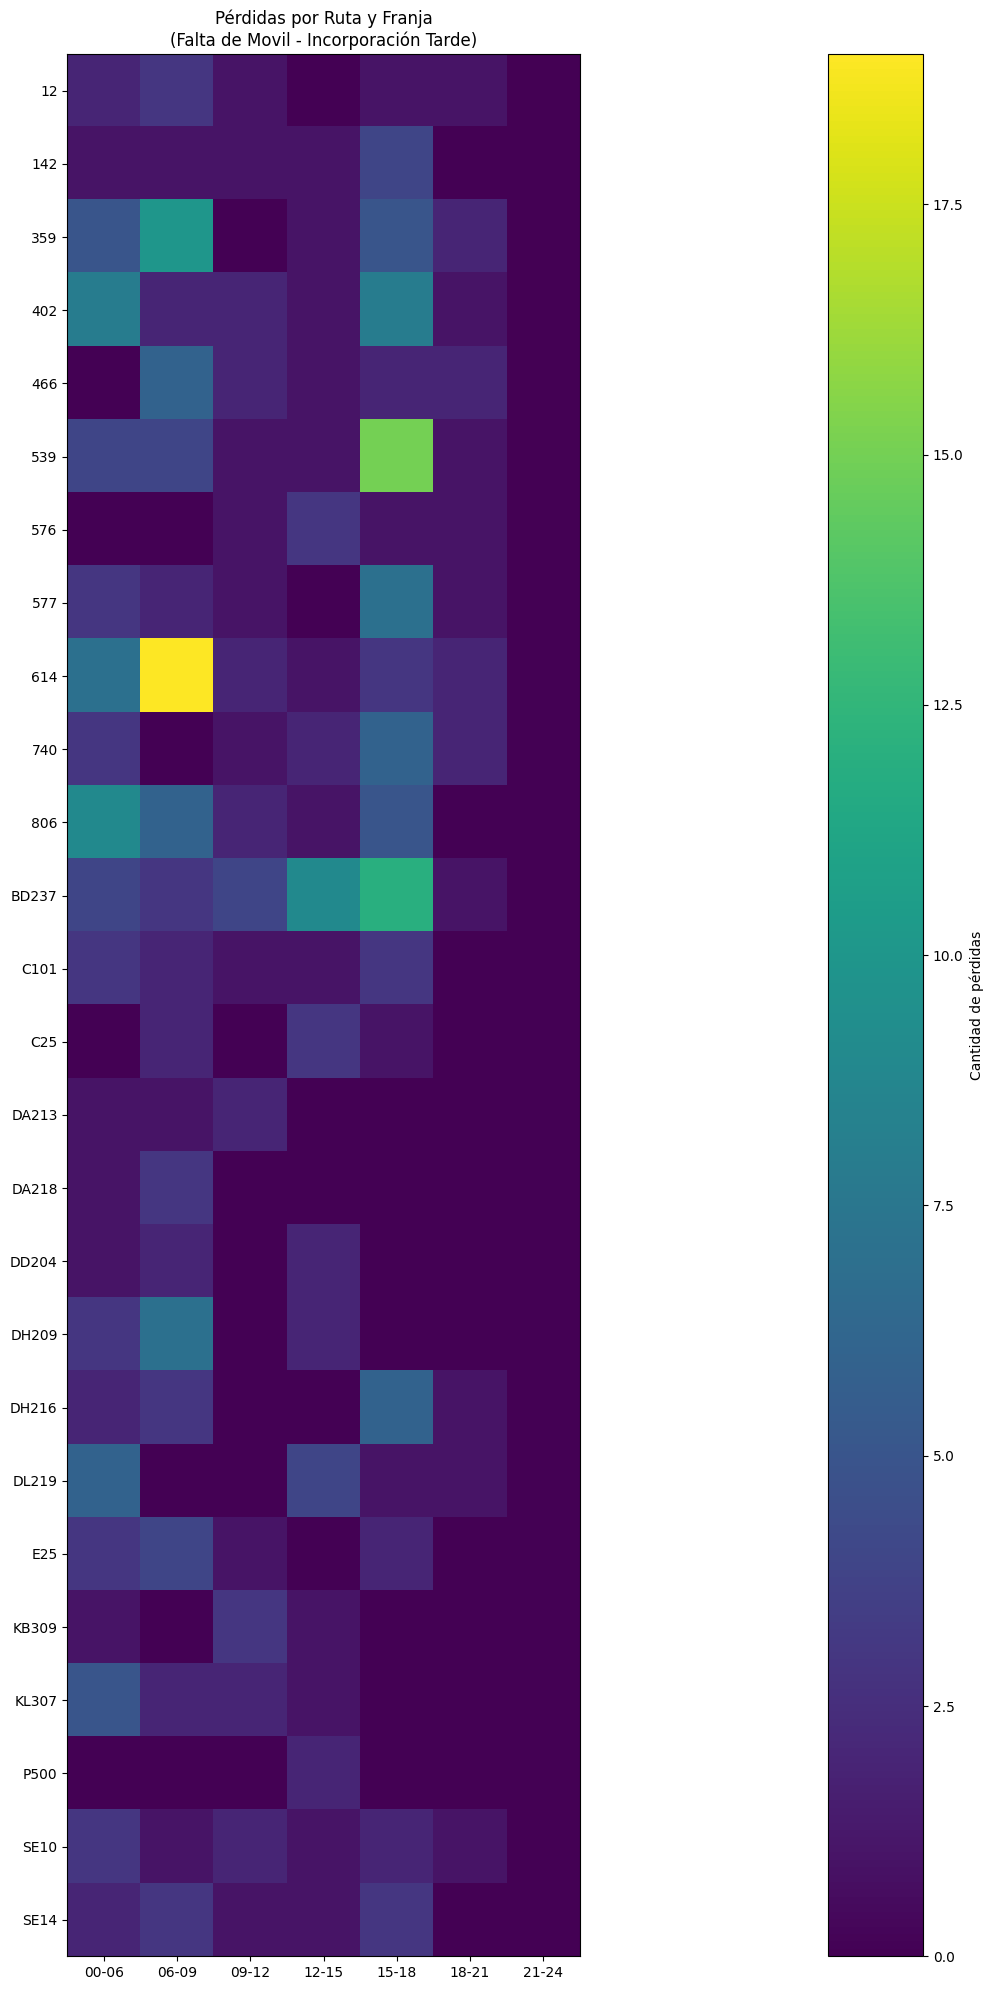

In [15]:
import matplotlib.pyplot as plt

# Pivot para matriz
pivot = tabla_ruta_franja.pivot(
    index="RUTA",
    columns="Franja",
    values="cantidad"
).fillna(0)

plt.figure(figsize=(50,20))
plt.imshow(pivot)

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.colorbar(label="Cantidad de pérdidas")
plt.title("Pérdidas por Ruta y Franja\n(Falta de Movil - Incorporación Tarde)")

plt.tight_layout()
plt.show()

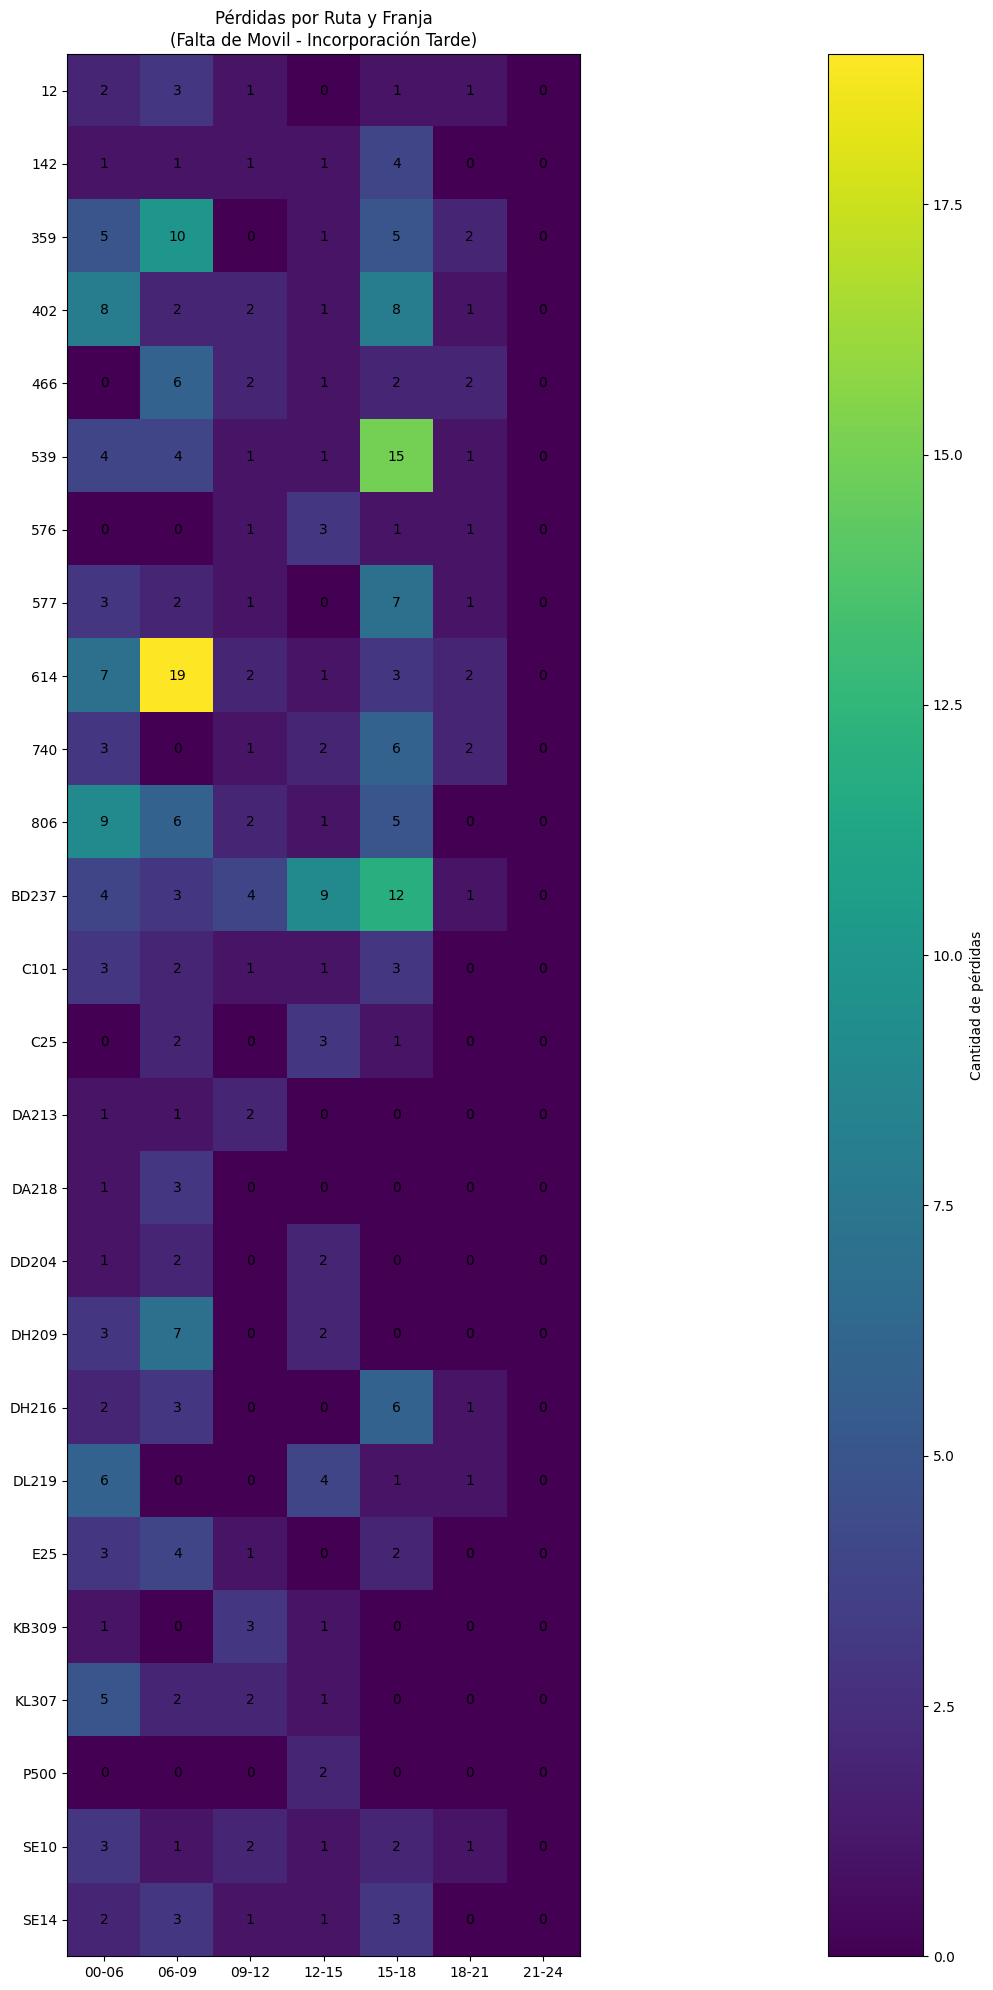

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Crear matriz
pivot = tabla_ruta_franja.pivot(
    index="RUTA",
    columns="Franja",
    values="cantidad"
).fillna(0)

plt.figure(figsize=(50,20))

# Mostrar matriz
im = plt.imshow(pivot.values)

# Ejes
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

# Etiquetas dentro de cada celda
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        valor = int(pivot.values[i, j])
        plt.text(
            j, i,
            valor,
            ha="center",
            va="center"
        )

plt.colorbar(label="Cantidad de pérdidas")
plt.title("Pérdidas por Ruta y Franja\n(Falta de Movil - Incorporación Tarde)")

plt.tight_layout()
plt.show()

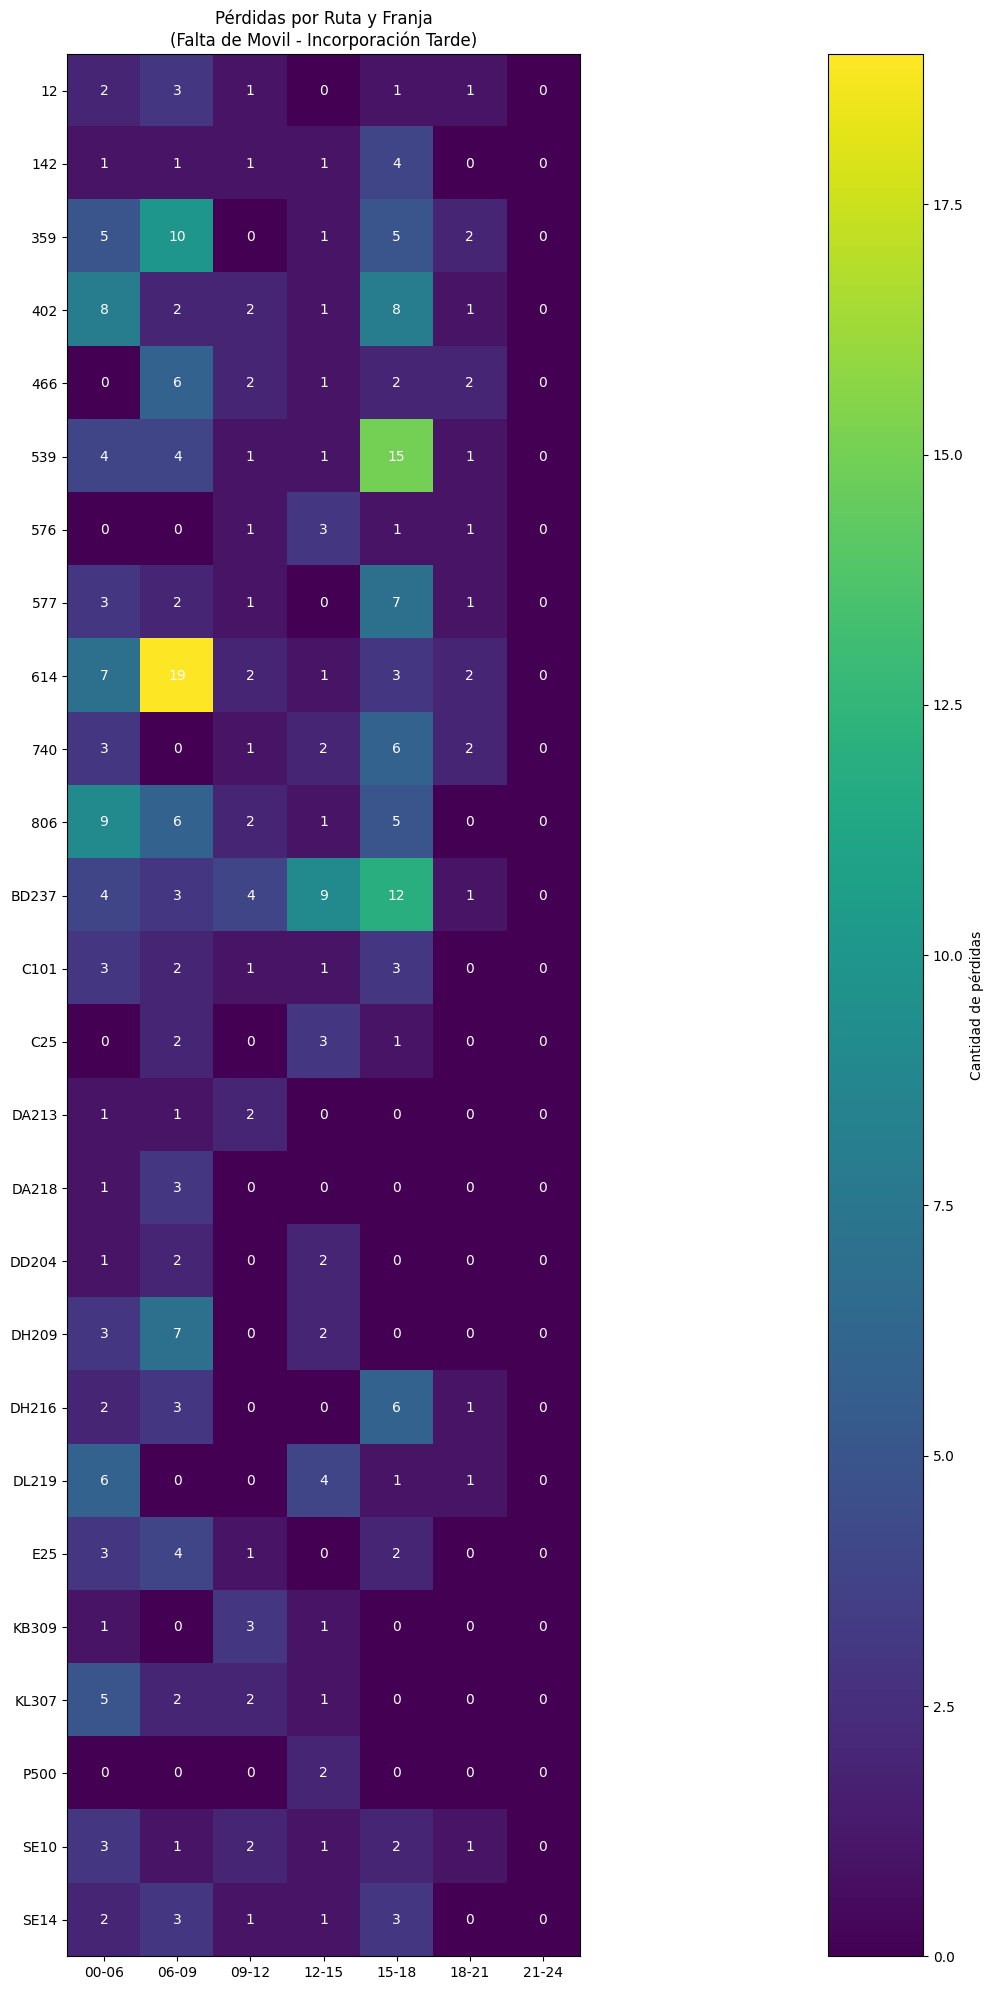

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Crear matriz
pivot = tabla_ruta_franja.pivot(
    index="RUTA",
    columns="Franja",
    values="cantidad"
).fillna(0)

plt.figure(figsize=(50,20))

# Mostrar matriz
im = plt.imshow(pivot.values)

# Ejes
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

# Etiquetas en color blanco
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        valor = int(pivot.values[i, j])
        plt.text(
            j, i,
            valor,
            ha="center",
            va="center",
            color="white"
        )

plt.colorbar(label="Cantidad de pérdidas")
plt.title("Pérdidas por Ruta y Franja\n(Falta de Movil - Incorporación Tarde)")

plt.tight_layout()
plt.show()

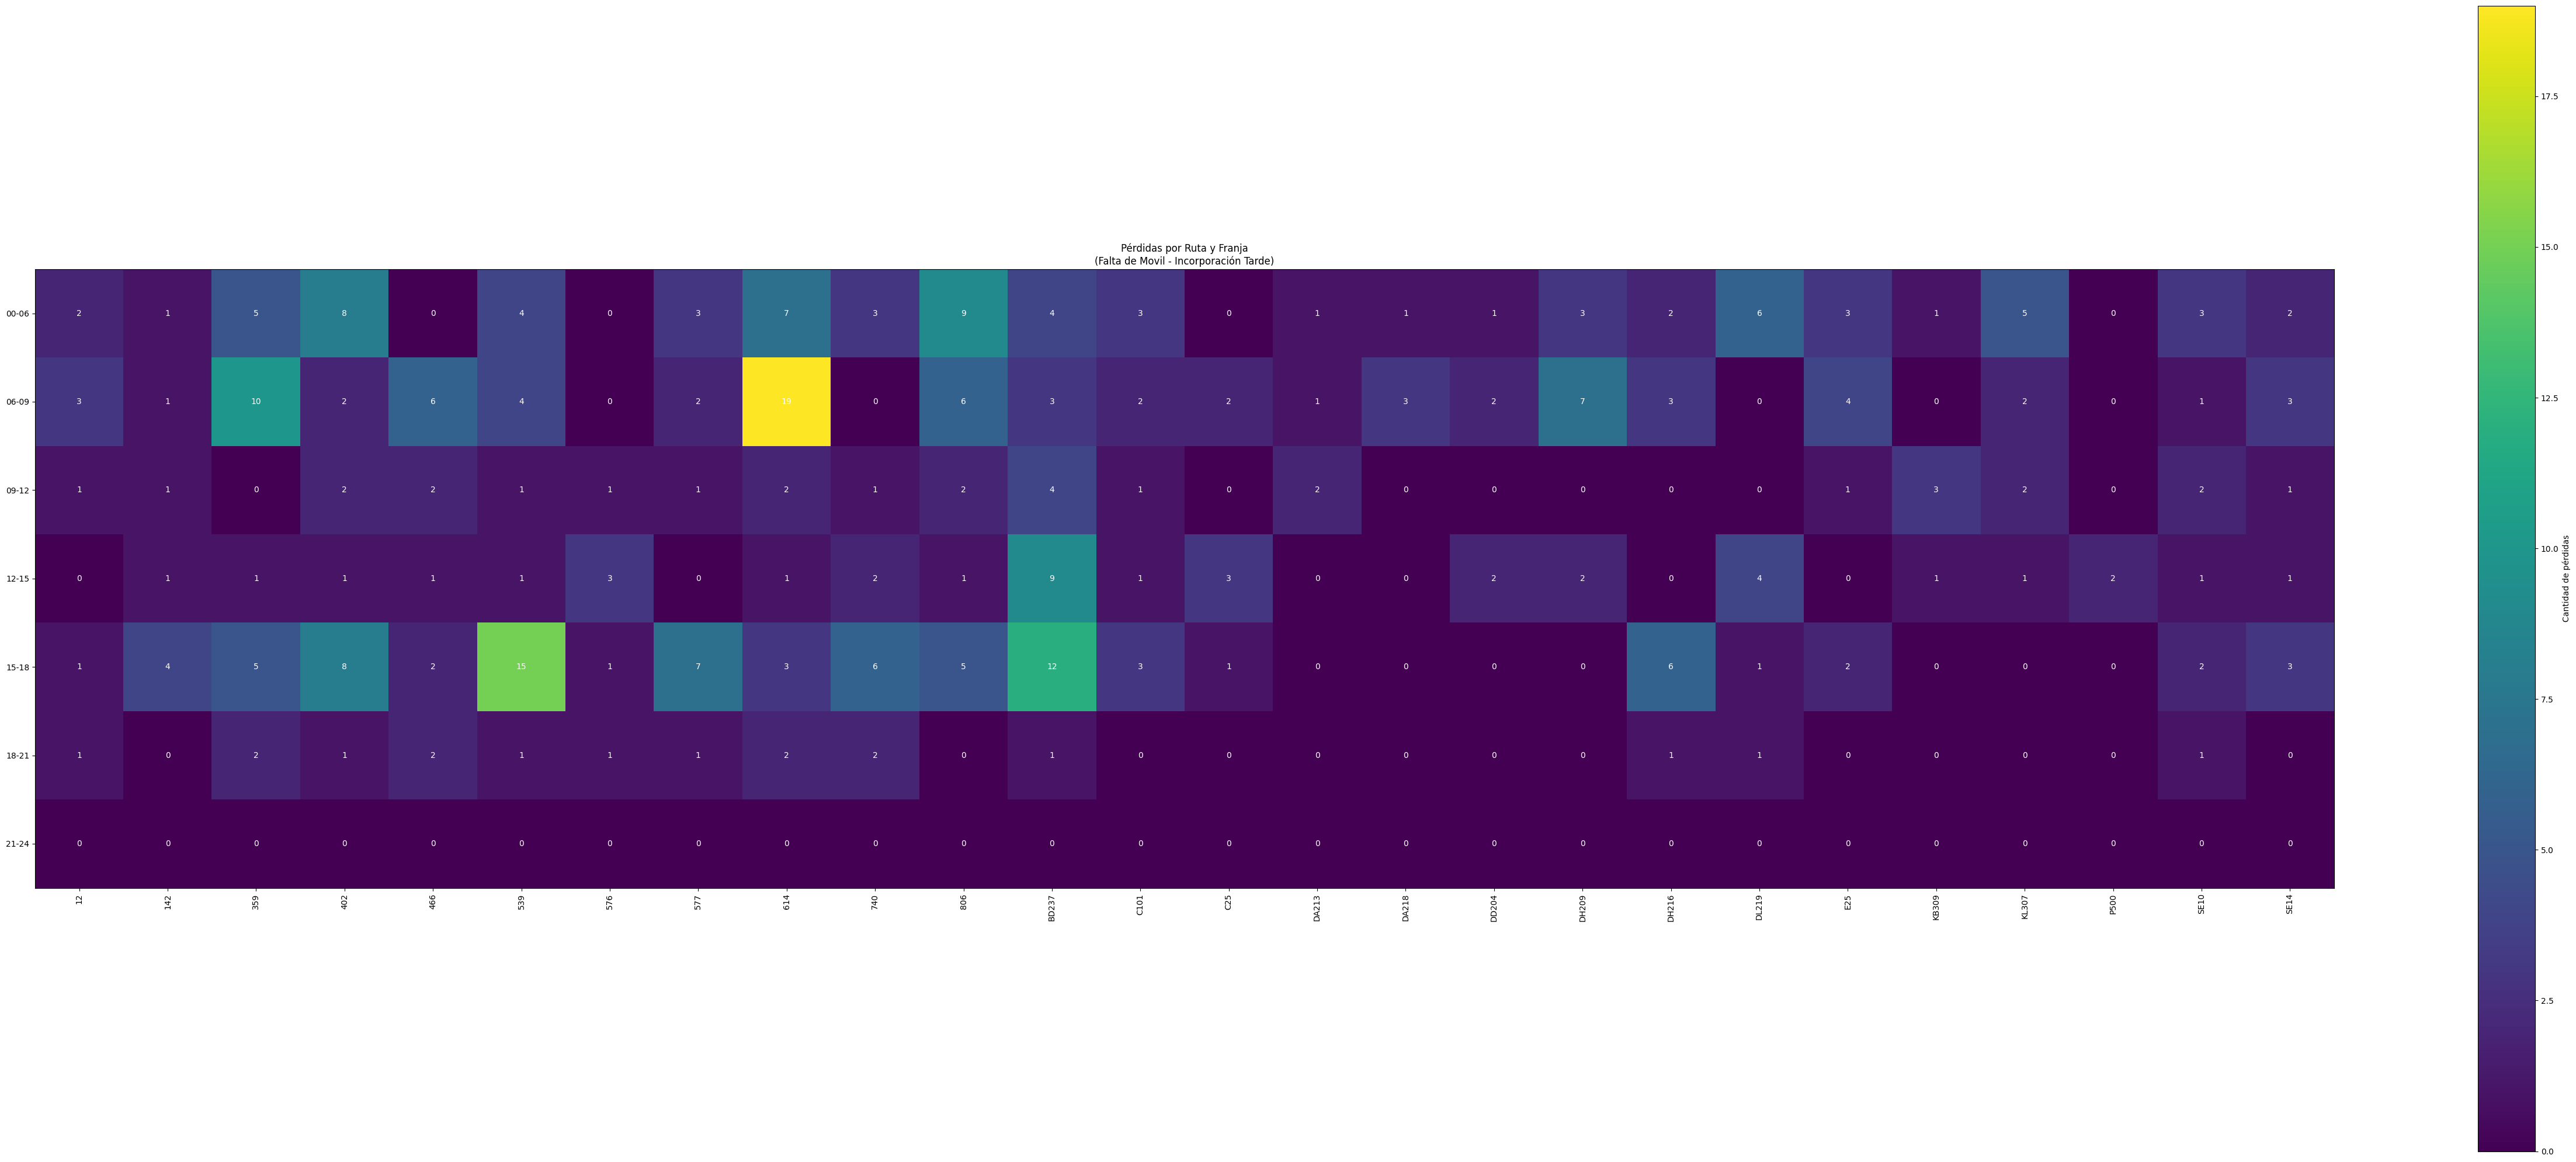

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot invertido
pivot = tabla_ruta_franja.pivot(
    index="Franja",     # Ahora Y
    columns="RUTA",     # Ahora X
    values="cantidad"
).fillna(0)

plt.figure(figsize=(50,20))

# Mostrar matriz
im = plt.imshow(pivot.values)

# Ejes
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)

# Etiquetas blancas
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        valor = int(pivot.values[i, j])
        plt.text(
            j, i,
            valor,
            ha="center",
            va="center",
            color="white"
        )

plt.colorbar(label="Cantidad de pérdidas")
plt.title("Pérdidas por Ruta y Franja\n(Falta de Movil - Incorporación Tarde)")

plt.tight_layout()
plt.show()

In [19]:
tabla_ruta_franja.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_perdidos/perdidas_franja.csv', sep=';', index=False)